In [1]:
# Imports
import time
import pandas as pd
from pandas import json_normalize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from xgboost import XGBRegressor

# Sklearn Imports
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Starting Point With Preloaded / Cleaned Datasets

In [2]:
# Merge all the dfs in one to prep training data
cleaning_df = pd.read_csv('model_weekly_team_game_stats.csv')
games_df = pd.read_csv('model_weekly_games.csv')
epa_df = pd.read_csv('team_game_epa_2016_2025.csv')
havoc_df = pd.read_csv('model_game_havoc(2016-2025).csv')

In [3]:
# Merge dfs together on game_id and team

games_df = games_df.drop(columns=['season','week'], errors='ignore')

merged_df = cleaning_df.merge(
    epa_df,
    on=['game_id','team'],
    how='inner')

merged_df = merged_df.merge(
    havoc_df,
    on=['game_id','team'],
    how='inner')

merged_df = merged_df.merge(
    games_df,
    on='game_id',
    how='inner')

In [4]:
# Drop redundant columns
merged_df = merged_df.drop(columns=[
    'season_y', 'season',
    'week_y', 'week',
    'opponent_y'], errors='ignore')

# Rename clean ones
merged_df = merged_df.rename(columns={
    'season_x': 'season',
    'week_x': 'week',
    'opponent_x': 'opponent'})

In [5]:
# Merge opponent 
game_df = merged_df.merge(
    merged_df,
    on='game_id',
    suffixes=('','_opp'))

# remove self matches
game_df = game_df[game_df['team'] != game_df['team_opp']]

# Create target (win column)
game_df['win'] = (game_df['points'] > game_df['points_opp']).astype(int)
game_df['margin'] = (game_df['points'] - game_df['points_opp'].astype(int))

In [ ]:
# Feature distribution


In [6]:
# Sort the data in to sequential order
game_df = game_df.sort_values(by=['team','season','week']).reset_index(drop=True)


################################################
# Create Features (Rolling Averages last 5 games)
roll_cols = [
    'totalYards','rushingYards','netPassingYards',
    'turnovers','firstDowns', 'points',
    'thirdDownConversions','fourthDownConversions',
    'sacks','tacklesForLoss',
    'off_epa','def_epa_allowed',
    'off_havoc','def_havoc']

for col in roll_cols:
    game_df[f'{col}_roll5'] = (
        game_df.groupby('team')[col]
        .transform(lambda x: x.shift(1).rolling(5).mean()))

################################################
# Sort for opponent rolling
game_df = game_df.sort_values(by=['team_opp','season','week'])

################################################    
# Create opponent rolling features
for col in roll_cols:
    game_df[f'{col}_opp_roll5'] = (
        game_df.groupby('team_opp')[f'{col}_opp']
        .transform(lambda x: x.shift(1).rolling(5).mean()))

################################################    
# Dop early rows with no history
roll_features = (
    [f'{col}_roll5' for col in roll_cols] +
    [f'{col}_opp_roll5' for col in roll_cols])
game_df = game_df.dropna(subset=roll_features)


################################################
# Keep only Rolling Features (+ Target)
feature_cols = [c for c in game_df.columns if 'roll5' in c]

X = game_df[feature_cols]
y = game_df['margin']
################################################

In [7]:
# Add Feature Difference
# This featrure will take the Main Team rolling 5 stats and subtract from the oppoenent rolling 5
for col in roll_cols:
    game_df[f'{col}_diff'] = (
        game_df[f'{col}_roll5'] - game_df[f'{col}_opp_roll5'])

diff_cols = [c for c in game_df.columns if '_diff' in c]

X = game_df[diff_cols]
y = game_df['margin']

In [8]:
# Handle missing values
X = X.fillna(0)

#Split the Data
# Split by season (example: train <= 2023, test = 2024+)

train_df = game_df[game_df['season'] <= 2023]
test_df  = game_df[game_df['season'] >= 2024]

X_train = train_df[X.columns]
y_train = train_df['margin']

X_test = test_df[X.columns]
y_test = test_df['margin']

# Fit the Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


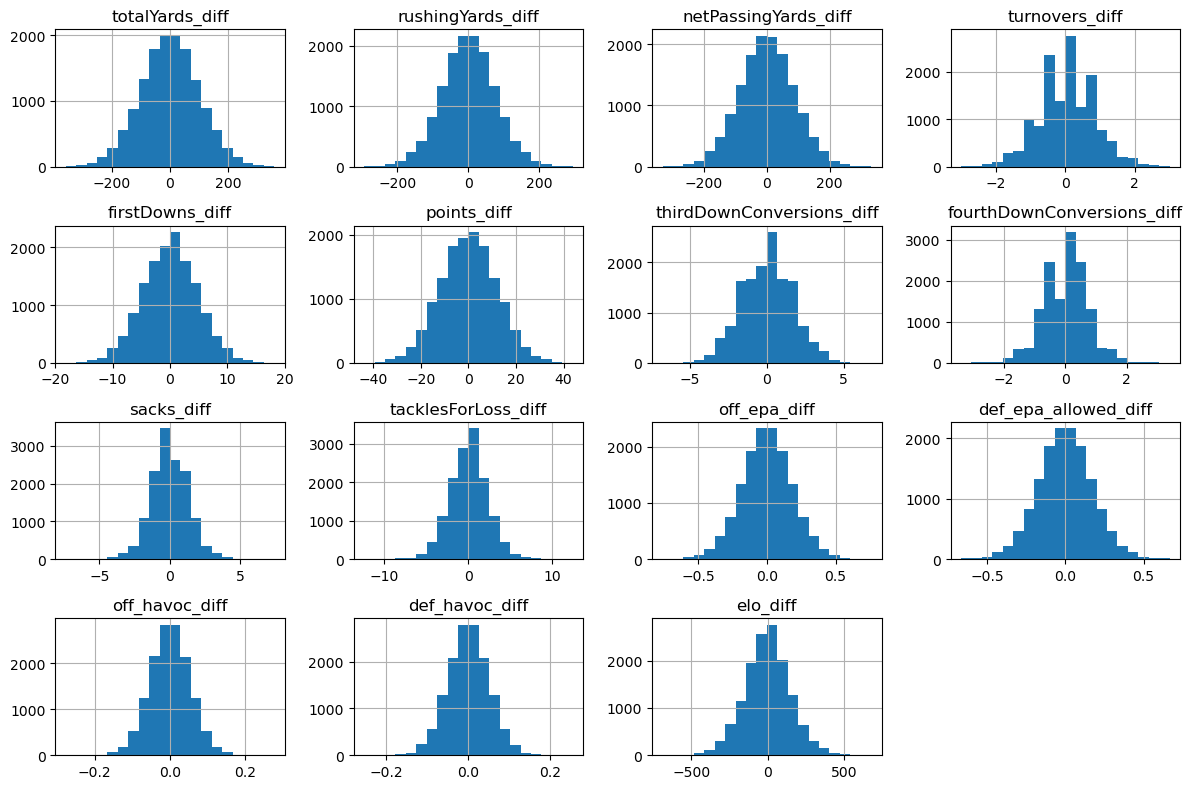

In [15]:
X.hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

In [9]:
importance = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importance}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
5,points_diff,0.214319
11,def_epa_allowed_diff,0.162112
10,off_epa_diff,0.091975
12,off_havoc_diff,0.067072
13,def_havoc_diff,0.057243
1,rushingYards_diff,0.052855
4,firstDowns_diff,0.050895
0,totalYards_diff,0.049639
2,netPassingYards_diff,0.048024
9,tacklesForLoss_diff,0.045908


In [ ]:
# Make Predictions
# Random Forest
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)
# Random Forest

15.526290983606556

In [11]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# Make Predictions
# XGBoost
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)
# XGBoost

15.451376914978027

In [13]:
# Initialize Elo ratings
elo_dict = {}

def get_elo(team):
    return elo_dict.get(team, 1500)

K = 20
elos = []
for _, row in game_df.iterrows():
    team = row['team']
    opp = row['team_opp']
    
    elo_team = get_elo(team)
    elo_opp = get_elo(opp)
    
    # Store pregame Elo
    elos.append((elo_team, elo_opp))
    
    # Expected result
    expected_team = 1 / (1 + 10 ** ((elo_opp - elo_team) / 400))
    
    # Actual result
    actual_team = 1 if row['win'] == 1 else 0
    
    # Update Elo
    elo_dict[team] = elo_team + K * (actual_team - expected_team)
    elo_dict[opp] = elo_opp + K * ((1 - actual_team) - (1 - expected_team))

# Add to dataframe
game_df[['elo','elo_opp']] = pd.DataFrame(elos, index=game_df.index)

In [ ]:
game_df['elo_diff'] = game_df['elo'] - game_df['elo_opp']
X = X.copy()
X['elo_diff'] = game_df.loc[X.index, 'elo_diff']
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)
# XGBoost with Elo

15.451376914978027